In [6]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from tools import *
from scipy.stats import linregress


In [7]:
file_path = f'/Users/kellyhui/Downloads/RBG_data/4_9_26/KH_RBG_otr_040826_KF_P6_post_anc.csv'
df = pd.read_csv(f'{file_path}') 
df_anc = clean_and_transpose(df, 25, 63).dropna().transpose()
df_anc = df_anc.reset_index()
df_anc.columns = ['Well', 'OD']
df_anc

def tidy_plate(df, plate_num):

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)
    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD']]

tidy_anc = tidy_plate(df_anc, 7)
bio_rep_anc = tidy_anc.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() 

In [8]:
dataframes = []
for i in range(1, 7):
    file_path = f'/Users/kellyhui/Downloads/RBG_data/4_9_26/KH_RBG_otr_040826_KF_P6_post_{i}.csv'
    df = pd.read_csv(f'{file_path}') 
    df = clean_and_transpose(df, 24, 122).dropna().transpose()
    df = df.reset_index()
    df.columns = ['Well', 'OD']
    dataframes.append(df)

#assign phage doses
def tidy_plate(df, plate_num):

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)

    H_mean = df[df['BioRep'] == 'H']['OD'].mean()
    print(H_mean)
    df['OD_subtracted'] = df['OD'] - H_mean

    df = df[df['BioRep'] != 'H']

    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD', 'OD_subtracted']]

tbl_arr = [tidy_plate(dataframes[i], i+1) for i in range(6)]
tbl_arr.append(tidy_anc)

#group plate, biol rep, and dose
bio_rep_mean = [tbl.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() for tbl in tbl_arr]
#bio_rep_mean.append(bio_rep_anc)

0.15937500125
0.19449166708333332
0.22929166508333332
0.10722499966666667
0.25239166499999993
0.2556166673333334


In [9]:
for i, df in enumerate(bio_rep_mean):
    plt.figure()

    df = df.copy()
    df['Dose_plot'] = df['Dose'].apply(lambda x: 0 if x == 0 else np.log10(x))

    # get R² for THIS plate
    r_df = r2_table[r2_table['Plate'] == (i + 1)]

    for bio in df['BioRep'].unique():
        bio_df = df[df['BioRep'] == bio]

        # safely get R²
        match = r_df[r_df['BioRep'] == bio]

        if len(match) == 0:
            r2 = np.nan
            p = np.nan
        else:
            r2 = match['R2'].values[0]
            p = match['p_value'].values[0]

        plt.plot(
            bio_df['Dose_plot'],
            bio_df['OD'],
            marker='o',
            alpha=0.7,
            label=f'BioRep {bio} (R²={r2:.2f}, p={p:.2g})'
        )

    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(f'Dose-response curves for Plate {i+1} at hour 12')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.1, 1.4)
    plt.show()

    #A-0.7,0.71,0.72
    #D-0.93,0.8,0.92

NameError: name 'r2_table' is not defined

<Figure size 640x480 with 0 Axes>

# Population Level

In [10]:
plate_results = []

for df in tbl_arr:
    df = df.copy()

    # log transform (handle 0)
    df["Dose_log"] = np.log10(df["Dose"] + 0.01)

    x = df["Dose_log"].values
    y = df["OD"].values

    if len(x) < 2:
        continue

    slope, intercept, r_value, p_value, _ = linregress(x, y)

    plate_results.append({
        "Plate": df["Plate"].iloc[0],
        "R2": r_value**2,
        "p_value": p_value,
        "slope": slope
    })

plate_table = pd.DataFrame(plate_results)
plate_table 

,Plate,R2,p_value,slope
0,1,0.003821,5.764309e-01,-0.001790
1,2,0.118346,1.354837e-03,-0.015306
2,3,0.035096,8.793114e-02,-0.008646
3,4,0.062143,2.221212e-02,-0.011251
4,5,0.011639,3.286565e-01,-0.004382
5,6,0.014816,2.700409e-01,-0.004300
6,7,0.596157,3.492293e-08,-0.059171


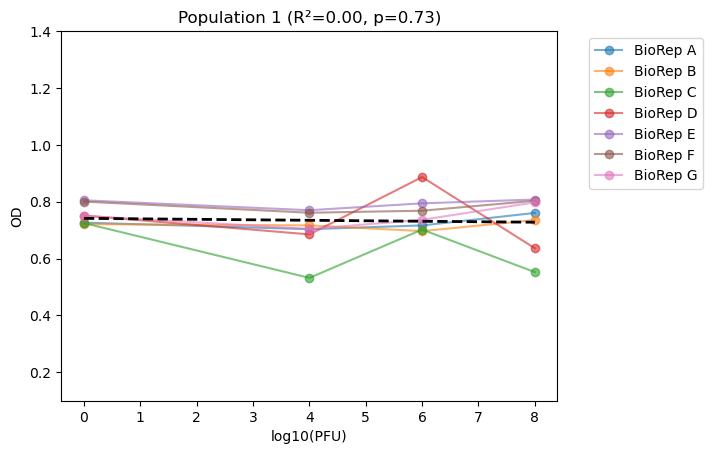

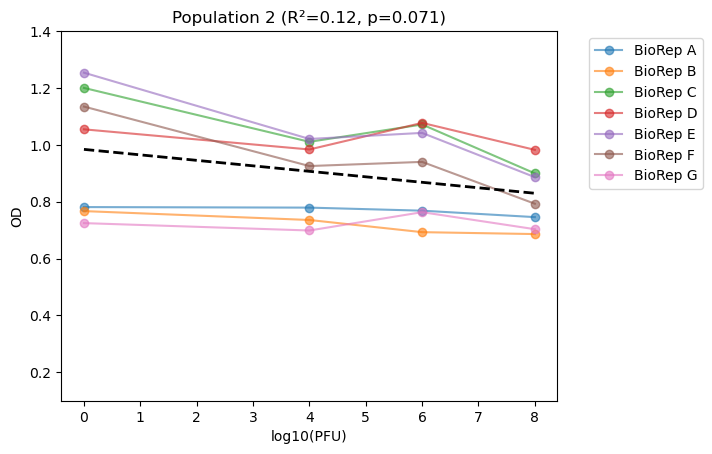

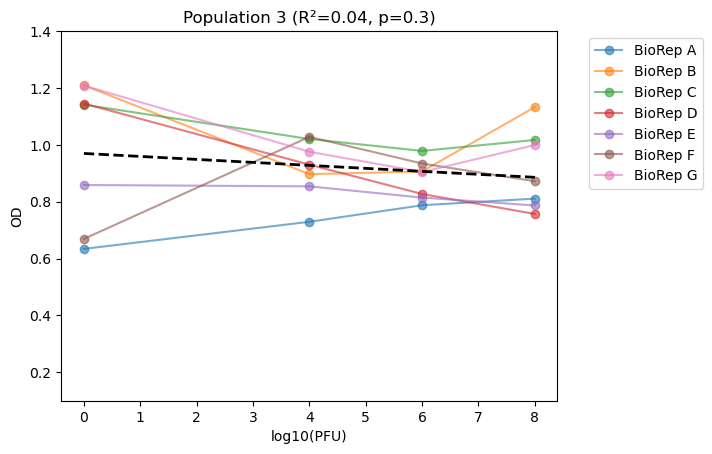

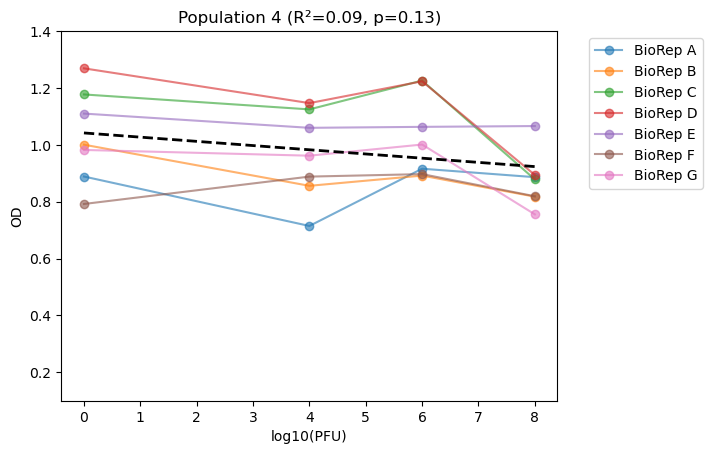

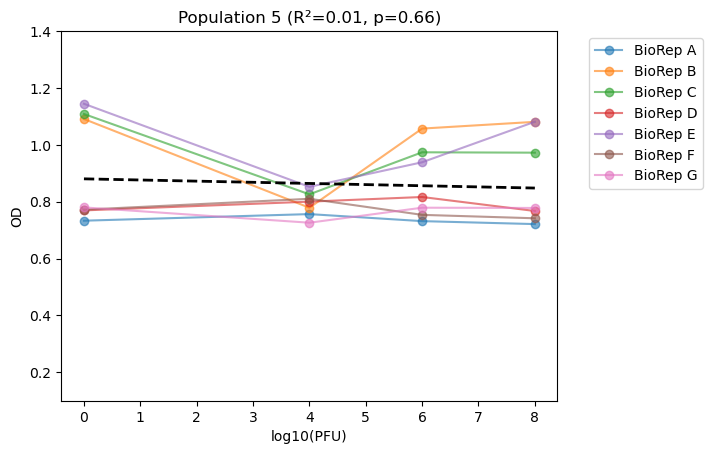

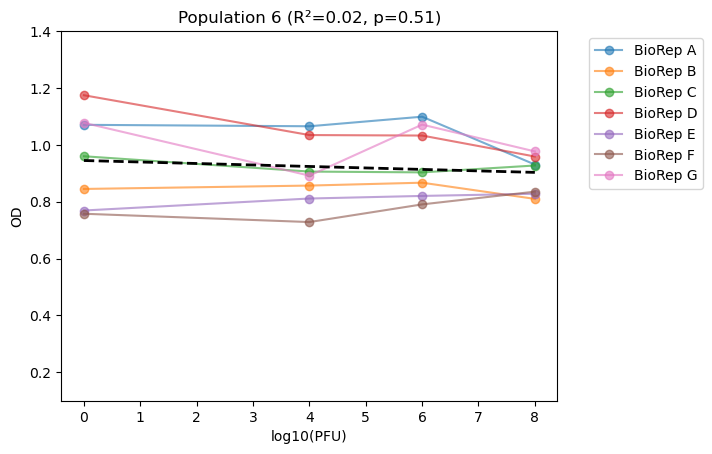

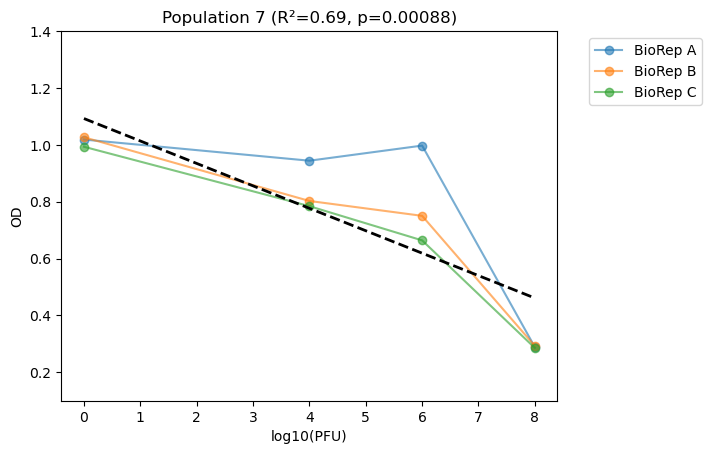

In [11]:
for i, df in enumerate(bio_rep_mean):
    plt.figure()

    df = df.copy()
    df['Dose_plot'] = df['Dose'].apply(lambda x: 0 if x == 0 else np.log10(x))

    x_all = df['Dose_plot'].values
    y_all = df['OD'].values

    slope, intercept, r_value, p_value, _ = linregress(x_all, y_all)
    r2 = r_value**2

    #plot each BioRep
    for bio in df['BioRep'].unique():
        bio_df = df[df['BioRep'] == bio]

        plt.plot(
            bio_df['Dose_plot'],
            bio_df['OD'],
            marker='o',
            alpha=0.6,
            label=f'BioRep {bio}'
        )


    #plot the regression line
    x_line = np.linspace(min(x_all), max(x_all), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linestyle='--', linewidth=2, color='black')

    # --- labels ---
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(
        f'Population {i+1} (R²={r2:.2f}, p={p_value:.2g})'
    )

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.1, 1.4)

    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg
from scipy.interpolate import interp1d

bio_reps = tbl_arr[0]['BioRep'].unique()
plates = range(len(tbl_arr))

ic50_table = pd.DataFrame(index=plates, columns=bio_reps, dtype=float)

for plate in plates:
    
    plate_df = tbl_arr[plate]
    plt.figure(figsize=(10,6))
    
    for bio in bio_reps:
        bio_df = plate_df[plate_df['BioRep'] == bio]

        x_vals = bio_df['Dose'].values
        y_vals = bio_df['OD'].values

        # Log10 transform dose for smoothing
        x_log = np.where(x_vals == 0, 0, np.log10(x_vals))
        if len(x_vals) == 0 or len(y_vals) == 0:
            continue

        # Fit local linear kernel regression
        
        kr = KernelReg(endog=y_vals, exog=x_log, var_type='c', reg_type='ll', bw=[0.5])
        x_grid = np.linspace(x_log.min(), x_log.max(), 200)
        y_pred_grid, _ = kr.fit(x_grid)

        # Half-max OD
        half_max = (y_pred_grid.max() + y_pred_grid.min()) / 2

        # Find IC50: x where smoothed OD crosses half-max
        try:
            f_interp = interp1d(y_pred_grid, x_grid, bounds_error=False, fill_value="extrapolate")
            ic50_log = f_interp(half_max)
        except:
            ic50 = np.nan

        ic50_table.loc[plate, bio] = ic50_log

        plt.scatter(x_log, y_vals, alpha=0.5, s=40, label=f'{bio} raw')
        plt.plot(x_grid, y_pred_grid, lw=2, label=f'{bio} smooth')
        plt.axvline(ic50_log, linestyle='--', alpha=0.5)

    #plt.xlabel('log10(PFU)')
    #plt.ylabel('OD')
    #plt.legend(bbox_to_anchor=(1.05, 1))
    #plt.grid(True)
    #plt.show()

ic50_table

# Pop Level

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vals = ic50_table.values.flatten()[:-3]
vals = vals[~np.isnan(vals)]

plt.figure(figsize=(8, 5))
plt.hist(vals, bins=20, edgecolor='black')

for v in (vals[-3:]):
    plt.axvline(v, color='red', linestyle='--', alpha=0.5)

plt.xlabel('log10(IC50)')
plt.ylabel('Count')
plt.title('Distribution of IC50 values')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Flatten by plate groups
group1_plates = [2, 5]
group2_plates = [1, 3, 4, 6]

group1_vals = ic50_table.loc[group1_plates].values.flatten()
group2_vals = ic50_table.loc[group2_plates].values.flatten()

# Remove NaNs
group1_vals = group1_vals[~np.isnan(group1_vals)]
group2_vals = group2_vals[~np.isnan(group2_vals)]

plt.figure(figsize=(8, 5))

# Histograms
plt.hist(group1_vals, bins=20, alpha=0.6, label='Plates 2,5')
plt.hist(group2_vals, bins=20, alpha=0.6, label='Plates 1, 3, 4, 6')

# Highlight last 3 values (still works)
vals = ic50_table.values.flatten()
vals = vals[~np.isnan(vals)]

for v in vals[-3:]:
    plt.axvline(v, color='red', linestyle='--', alpha=0.5)

plt.xlabel('log10(IC50)')
plt.ylabel('Count')
plt.title('Distribution of IC50 values KF (blue = phage, orange = no phage)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
bio_rep_mean = [tbl.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() for tbl in tbl_arr]
combined_df = pd.concat(bio_rep_mean, ignore_index=True)
combined_df = combined_df[combined_df['Plate'] != 6]
variance_summary = (
    combined_df
    .groupby(['Plate', 'Dose'])
    .agg(
        mean_OD=('OD', 'mean'),
        variance_OD=('OD', 'var'),
        sd_OD=('OD', 'std')
    )
    .reset_index()
)

variance_summary['CV'] = (
    variance_summary['sd_OD'] /
    variance_summary['mean_OD']
)

variance_summary['CV'].mean()

np.float64(0.13367023724656657)